**1- load data and split**

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# load MNIST and preprocess (integer)
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.uint8)
y = y.astype(np.uint8)

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X[:30000], y[:30000],
    test_size=0.3,
    random_state=42,
    stratify=y[:30000])

assert all(np.bincount(y_train) >= 10) # 10 examples of each label

**2- function for plot image**

In [29]:
import matplotlib.pyplot as plt

def plot_image(index, images, labels):
    plt.imshow(images[index].reshape(28, 28), cmap='gray_r')
    plt.title(f"Label: {labels[index]}")
    plt.axis('on')
    plt.show()

**3- train SVM model with 3 different kernels**

In [12]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# parameters for each kernel
param_grid_linear = {'kernel': ['linear'], 'C': [0.1, 1, 10]}
param_grid_poly = {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2], 'coef0': [0, 1]}
param_grid_rbf = {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}

# grid search
for param_grid in [param_grid_linear, param_grid_poly, param_grid_rbf]:
    grid_search = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=3)
    grid_search.fit(X_train, y_train)
    print(f"Best parameters for {param_grid['kernel'][0]} kernel: {grid_search.best_params_}")
    print(f"Best score for {param_grid['kernel'][0]} kernel: {grid_search.best_score_}\n")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for linear kernel: {'C': 0.1, 'kernel': 'linear'}
Best score for linear kernel: 0.9117619047619048

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters for poly kernel: {'C': 10, 'coef0': 0, 'degree': 2, 'kernel': 'poly'}
Best score for poly kernel: 0.9690952380952381

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters for rbf kernel: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best score for rbf kernel: 0.9735238095238096



**4- report best SVM model**

In [13]:
# best SVM model
best_model = grid_search.best_estimator_
best_score = grid_search.best_score_
best_params = grid_search.best_params_
print(f"Best SVM model score: {best_score}")
print(f"Best SVM model parameters: {best_params}")

Best SVM model score: 0.9735238095238096
Best SVM model parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


**5- train and evaluate best SVM model**

In [14]:
from sklearn.metrics import accuracy_score

# train SVM model and report error
best_model.fit(X_train, y_train)
train_predictions = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
train_error = 1 - train_accuracy
test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
test_error = 1 - test_accuracy
print(f"Training Error: {train_error}")
print(f"Test Error: {test_error}")

Training Error: 9.523809523814819e-05
Test Error: 0.02200000000000002


**6- train and evaluate Logistic Regression model**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# scaling and logistic regression
log_reg_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# train model and report error
log_reg_pipeline.fit(X_train, y_train)
log_reg_predictions = log_reg_pipeline.predict(X_test)
log_reg_accuracy = accuracy_score(y_test, log_reg_predictions)
log_reg_error = 1 - log_reg_accuracy
print(f"Logistic Regression Test Error: {log_reg_error}")

Logistic Regression Test Error: 0.11111111111111116


**7- displaying image misclassified by logistic regression but correctly classified by best SVM model**

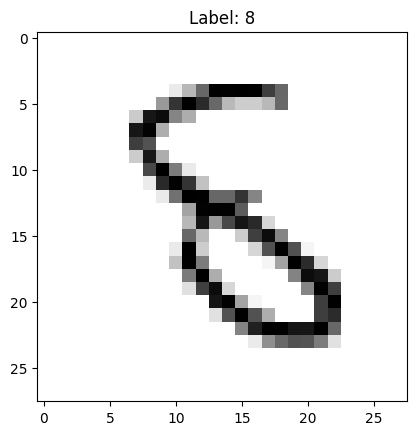


Logistic Regression predicted: 6 
SVM predicted: 8


In [30]:
# wrong predict in logistic regression
log_reg_misclassified = np.where(log_reg_predictions != y_test)[0]

# correct predict in SVM
svm_predictions = best_model.predict(X_test.iloc[log_reg_misclassified])
svm_correct = np.where(svm_predictions == y_test.iloc[log_reg_misclassified])[0]

if len(svm_correct) > 0:
    index = svm_correct[0]
    misclassified_index = log_reg_misclassified[index]

    # display image and label predictions
    plot_image(misclassified_index, X_test.to_numpy(), y_test.to_numpy())
    print(f"\nLogistic Regression predicted: {log_reg_predictions[misclassified_index]} \nSVM predicted: {svm_predictions[index]}")
else:
    print("NOT FOUND!")


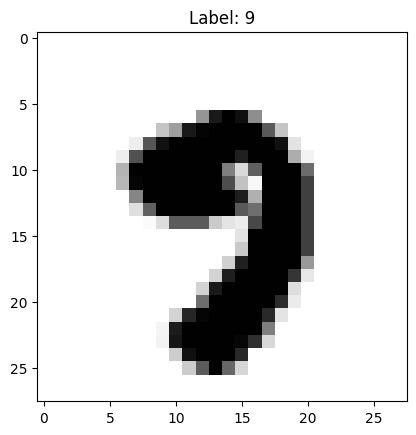


Logistic Regression predicted: 7 
SVM predicted: 9


In [31]:
# wrong predict in logistic regression
log_reg_misclassified = np.where(log_reg_predictions != y_test)[0]

# correct predict in SVM
svm_predictions = best_model.predict(X_test.iloc[log_reg_misclassified])
svm_correct = np.where(svm_predictions == y_test.iloc[log_reg_misclassified])[0]

if len(svm_correct) > 0:
    index = svm_correct[1]
    misclassified_index = log_reg_misclassified[index]

    # display image and label predictions
    plot_image(misclassified_index, X_test.to_numpy(), y_test.to_numpy())
    print(f"\nLogistic Regression predicted: {log_reg_predictions[misclassified_index]} \nSVM predicted: {svm_predictions[index]}")
else:
    print("NOT FOUND!")

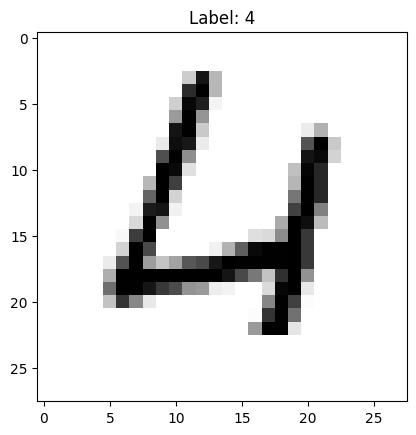


Logistic Regression predicted: 2 
SVM predicted: 4


In [32]:
# wrong predict in logistic regression
log_reg_misclassified = np.where(log_reg_predictions != y_test)[0]

# correct predict in SVM
svm_predictions = best_model.predict(X_test.iloc[log_reg_misclassified])
svm_correct = np.where(svm_predictions == y_test.iloc[log_reg_misclassified])[0]

if len(svm_correct) > 0:
    index = svm_correct[2]
    misclassified_index = log_reg_misclassified[index]

    # display image and label predictions
    plot_image(misclassified_index, X_test.to_numpy(), y_test.to_numpy())
    print(f"\nLogistic Regression predicted: {log_reg_predictions[misclassified_index]} \nSVM predicted: {svm_predictions[index]}")
else:
    print("NOT FOUND!")